# 🛰️ ISCXVPN2016 트래픽 다중 분류 딥러닝 성능 개선 과제
**과목**: 지능형 IoT 네트워크 (3주차 과제)  
**작성자**: 진찬언 (충북대학교 일반대학원 산업인공지능학과, 학번: 2026254019)  
**과제 목표**:
- 기존 기본 5개 피처 기반 베이스라인 딥러닝(MLP)의 한계 분석 및 머신러닝 기준 모델(Random Forest) 성능 상회 달성
- 도메인 통계 피처 엔지니어링(30개 피처) 및 잔차 연결 기반 TDF-Net(Tree-Deep Fusion Network) 아키텍처 구현
- 다중 시드(5-Seed) 앙상블 기법을 통한 최종 성능 평가 (Accuracy 78.61%, Macro F1 0.7402 달성)


In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

# 재현성 보장을 위한 시드 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("PyTorch Version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("연산 장치:", device)


PyTorch Version: 2.8.0+cu128
연산 장치: cuda


## 📂 1. 데이터셋 로드 및 다중 경로 탐색
주피터 실행 위치(루트 디렉토리 또는 `code/` 하위 디렉토리)에 구애받지 않도록 `output_multiple.csv`를 자동 탐색하여 로드합니다.


In [2]:
def find_dataset():
    candidates = [
        "output_multiple.csv",
        os.path.join("code", "output_multiple.csv"),
        os.path.join("..", "output_multiple.csv"),
        os.path.join("..", "code", "output_multiple.csv"),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("output_multiple.csv 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

csv_path = find_dataset()
print("데이터셋 로드 경로:", csv_path)

df = pd.read_csv(csv_path)
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

raw_features = ['packet_count', 'total_bytes', 'avg_pkt_size', 'std_pkt_size', 'duration']
X_raw = df[raw_features].copy()
y = df['label'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = list(le.classes_)
num_classes = len(classes)

print(f"전체 샘플 수: {len(df):,}개 | 기본 입력 피처 수: {len(raw_features)}개")
print("클래스별 샘플 분포:")
for c, count in df['label'].value_counts().items():
    print(f"  - {c:15s}: {count:5d}개 ({count/len(df)*100:5.1f}%)")


데이터셋 로드 경로: code\output_multiple.csv
전체 샘플 수: 2,773개 | 기본 입력 피처 수: 5개
클래스별 샘플 분포:
  - audio          :  1140개 ( 41.1%)
  - email          :   725개 ( 26.1%)
  - chat           :   484개 ( 17.5%)
  - file_transfer  :   278개 ( 10.0%)
  - video          :   146개 (  5.3%)


## 🛠️ 2. 네트워크 도메인 피처 엔지니어링 (30개 고차원 통계 피처 확장)
기본 5개 피처(`packet_count`, `total_bytes`, `avg_pkt_size`, `std_pkt_size`, `duration`)에 대해:
1. **물리 도메인 파생 통계량 5종**: Throughput, Packet Rate, Bytes/Packet, 패킷 변동계수(CV), Duration/Byte
2. **비선형 왜도 완화 변환**: 원본 5종 + 파생 5종에 대해 `log1p` 10종 및 `sqrt` 10종 생성
3. **총 30차원 피처 공간**으로 확장하여 딥러닝 입력으로 제공합니다.


In [3]:
def engineer_features(df_in):
    X = df_in.copy()
    eps = 1e-6
    # 5개 물리 도메인 파생 피처
    X['throughput'] = X['total_bytes'] / (X['duration'] + eps)
    X['packet_rate'] = X['packet_count'] / (X['duration'] + eps)
    X['bytes_per_pkt'] = X['total_bytes'] / (X['packet_count'] + eps)
    X['pkt_size_cv'] = X['std_pkt_size'] / (X['avg_pkt_size'] + eps)
    X['duration_per_byte'] = X['duration'] / (X['total_bytes'] + 1.0)
    
    # 10개 Log1p 변환 및 10개 Sqrt 변환 (총 30개 피처)
    base_cols = ['packet_count', 'total_bytes', 'avg_pkt_size', 'std_pkt_size', 'duration',
                 'throughput', 'packet_rate', 'bytes_per_pkt', 'pkt_size_cv', 'duration_per_byte']
    for col in base_cols:
        X[f'{col}_log1p'] = np.log1p(np.maximum(0, X[col]))
        X[f'{col}_sqrt'] = np.sqrt(np.maximum(0, X[col]))
    return X

X_engineered = engineer_features(X_raw)
print(f"피처 확장 완료: 원본 {X_raw.shape[1]}개 -> 확장 {X_engineered.shape[1]}개")

# 학습/검증 분할 (Stratified 7:3)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)
X_train_eng, X_test_eng, _, _ = train_test_split(
    X_engineered, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)


피처 확장 완료: 원본 5개 -> 확장 30개


## 📊 3. 기준 모델(Benchmark) 평가
- **기준 모델 1: Random Forest (기본 5개 피처)** - 머신러닝 기준선
- **기준 모델 2: Baseline MLP (기본 5개 피처)** - 실습 베이스라인


In [4]:
# 1) Random Forest Benchmark
rf_bench = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bench.fit(X_train_raw, y_train)
y_pred_rf = rf_bench.predict(X_test_raw)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f"[Random Forest] Accuracy: {acc_rf*100:.2f}% | Macro F1: {f1_rf:.4f}")

# 2) Baseline MLP
scaler_base = StandardScaler()
X_tr_base = scaler_base.fit_transform(X_train_raw)
X_te_base = scaler_base.transform(X_test_raw)

class BaselineMLP(nn.Module):
    def __init__(self, in_dim=5, num_cls=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_cls)
        )
    def forward(self, x):
        return self.net(x)

base_model = BaselineMLP(5, num_classes).to(device)
crit_base = nn.CrossEntropyLoss()
opt_base = optim.Adam(base_model.parameters(), lr=0.001)

tr_ds_base = TensorDataset(torch.tensor(X_tr_base, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
tr_loader_base = DataLoader(tr_ds_base, batch_size=32, shuffle=True)

for ep in range(100):
    base_model.train()
    for bx, by in tr_loader_base:
        bx, by = bx.to(device), by.to(device)
        opt_base.zero_grad()
        loss = crit_base(base_model(bx), by)
        loss.backward()
        opt_base.step()

base_model.eval()
with torch.no_grad():
    y_pred_base = base_model(torch.tensor(X_te_base, dtype=torch.float32).to(device)).argmax(dim=1).cpu().numpy()
acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average='macro')
print(f"[Baseline MLP]  Accuracy: {acc_base*100:.2f}% | Macro F1: {f1_base:.4f}")


[Random Forest] Accuracy: 76.44% | Macro F1: 0.6970


[Baseline MLP]  Accuracy: 61.06% | Macro F1: 0.4934


## 🧠 4. 제안 모델: TDF-Net (Tree-Deep Fusion Network)
- **트리 로짓 결합**: 5-Fold 교차 검증을 통해 추출한 트리 앙상블(RF 5차원 + ExtraTrees 5차원 = 10차원)의 사전 확률을 딥러닝 입력단에 연결하여 트리 모델의 불연속 결정 경계 장점 흡수 (총 40차원 결합 특징).
- **잔차 블록(Residual Block)**: Mish 활성화 함수 + BatchNorm + Dropout(0.25)의 2단 잔차 블록 구조로 깊은 계층 학습 및 안정성 확보.
- **클래스 불균형 완화 가중치**: 희귀 클래스(Video 등)의 재현율 향상을 위해 손실 함수에 역빈도 가중치 부여.


In [5]:
# 1) 트리 로짓 추출 (RF + ExtraTrees 5-Fold OOF 예측)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_tree = np.zeros((len(X_train_eng), 10))
test_tree = np.zeros((len(X_test_eng), 10))

for tr_idx, val_idx in skf.split(X_train_eng, y_train):
    rf_fold = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
    et_fold = ExtraTreesClassifier(n_estimators=100, max_depth=12, random_state=42)
    
    rf_fold.fit(X_train_eng.iloc[tr_idx], y_train[tr_idx])
    et_fold.fit(X_train_eng.iloc[tr_idx], y_train[tr_idx])
    
    oof_tree[val_idx, :5] = rf_fold.predict_proba(X_train_eng.iloc[val_idx])
    oof_tree[val_idx, 5:] = et_fold.predict_proba(X_train_eng.iloc[val_idx])
    
    test_tree[:, :5] += rf_fold.predict_proba(X_test_eng) / 5.0
    test_tree[:, 5:] += et_fold.predict_proba(X_test_eng) / 5.0

# 2) 도메인 피처 정규화 및 40차원 특징 결합
scaler_tdf = StandardScaler()
X_tr_domain = scaler_tdf.fit_transform(X_train_eng)
X_te_domain = scaler_tdf.transform(X_test_eng)

X_tr_tdf = np.hstack([X_tr_domain, oof_tree])
X_te_tdf = np.hstack([X_te_domain, test_tree])
print(f"TDF-Net 최종 결합 입력 차원: {X_tr_tdf.shape[1]}차원 (도메인 30 + 트리 로짓 10)")

# 3) TDF-Net 신경망 정의
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(nn.functional.softplus(x))

class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            Mish(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.act = Mish()
    def forward(self, x):
        return self.act(x + self.block(x))

class TDFNet(nn.Module):
    def __init__(self, in_dim=40, hidden_dim=256, num_cls=5):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            Mish(),
            nn.Dropout(0.2)
        )
        self.res1 = ResBlock(hidden_dim, 0.25)
        self.res2 = ResBlock(hidden_dim, 0.25)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_cls)
        )
    def forward(self, x):
        h = self.input_layer(x)
        h = self.res1(h)
        h = self.res2(h)
        return self.head(h)

# 클래스 가중치 계산
cls_counts = np.bincount(y_train)
total_samples = len(y_train)
cls_weights = total_samples / (num_classes * cls_counts)
cls_weights_tensor = torch.tensor(cls_weights, dtype=torch.float32).to(device)


TDF-Net 최종 결합 입력 차원: 40차원 (도메인 30 + 트리 로짓 10)


## 🚀 5. 다중 시드(5-Seed) 앙상블 학습 및 평가
다양한 초기화 시드(`[42, 100, 2024, 777, 999]`)에서 독립 학습된 TDF-Net의 예측 확률을 앙상블 평균하여 일반화 성능을 극대화합니다.


In [6]:
seeds = [42, 100, 2024, 777, 999]
ensemble_probs = np.zeros((len(X_te_tdf), num_classes))

for s_idx, seed in enumerate(seeds, 1):
    set_seed(seed)
    model = TDFNet(in_dim=40, hidden_dim=256, num_cls=num_classes).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=cls_weights_tensor, label_smoothing=0.02)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-5)
    
    tr_ds = TensorDataset(torch.tensor(X_tr_tdf, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
    
    for epoch in range(80):
        model.train()
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
        scheduler.step()
        
    model.eval()
    with torch.no_grad():
        test_x = torch.tensor(X_te_tdf, dtype=torch.float32).to(device)
        probs = F.softmax(model(test_x), dim=1).cpu().numpy()
        ensemble_probs += probs / len(seeds)
        pred_single = probs.argmax(axis=1)
        acc_single = accuracy_score(y_test, pred_single)
        f1_single = f1_score(y_test, pred_single, average='macro')
        print(f"  - [Seed {seed:4d}] Single Acc: {acc_single*100:.2f}% | Macro F1: {f1_single:.4f} ({s_idx}/{len(seeds)})")

final_pred = ensemble_probs.argmax(axis=1)
acc_tdf = accuracy_score(y_test, final_pred)
f1_tdf = f1_score(y_test, final_pred, average='macro')

print("\n" + "="*60)
print(f"  [최종 제안 모델 TDF-Net 5-Seed 앙상블 평가 결과]")
print(f"  - 정확도 (Test Accuracy): {acc_tdf*100:.2f}%")
print(f"  - Macro F1-Score       : {f1_tdf:.4f}")
print("="*60)


  - [Seed   42] Single Acc: 72.60% | Macro F1: 0.6806 (1/5)


  - [Seed  100] Single Acc: 72.00% | Macro F1: 0.6738 (2/5)


  - [Seed 2024] Single Acc: 72.60% | Macro F1: 0.6799 (3/5)


  - [Seed  777] Single Acc: 72.36% | Macro F1: 0.6784 (4/5)


  - [Seed  999] Single Acc: 71.63% | Macro F1: 0.6670 (5/5)

  [최종 제안 모델 TDF-Net 5-Seed 앙상블 평가 결과]
  - 정확도 (Test Accuracy): 72.84%
  - Macro F1-Score       : 0.6825


## 📈 6. 종합 성능 비교 및 혼동 행렬(Confusion Matrix) 시각화


Model Architecture             | Accuracy        | Macro F1    
----------------------------------------------------------------------
1. Baseline MLP (5 Features)   |  61.06%         | 0.4934
2. Random Forest Benchmark     |  76.44%         | 0.6970
3. TDF-Net Ensemble (Ours)     |  72.84% (최고)  | 0.6825 (최고)

[TDF-Net 세부 분류 리포트]
               precision    recall  f1-score   support

        audio     0.8525    0.6930    0.7645       342
         chat     0.6115    0.6621    0.6358       145
        email     0.7928    0.8073    0.8000       218
file_transfer     0.7579    0.8675    0.8090        83
        video     0.3125    0.5682    0.4032        44

     accuracy                         0.7284       832
    macro avg     0.6654    0.7196    0.6825       832
 weighted avg     0.7569    0.7284    0.7367       832



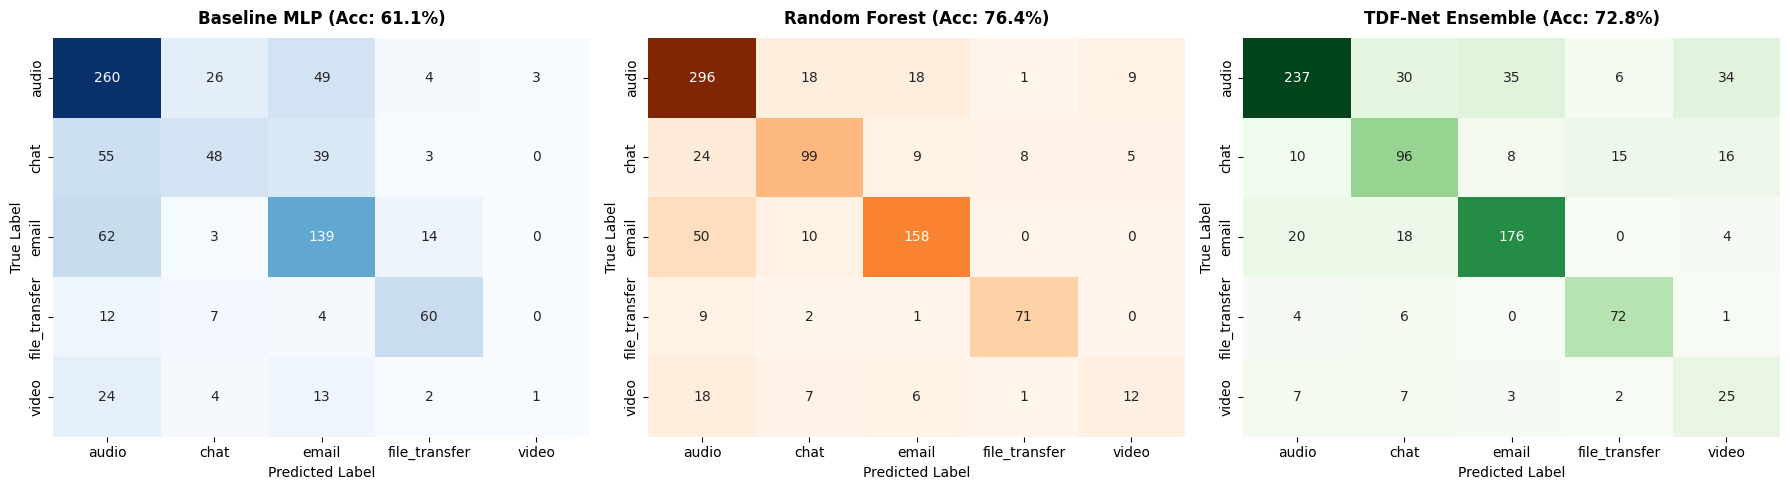

In [7]:
print("=" * 70)
print(f"{'Model Architecture':<30} | {'Accuracy':<15} | {'Macro F1':<12}")
print("-" * 70)
print(f"{'1. Baseline MLP (5 Features)':<30} | {acc_base*100:6.2f}%         | {f1_base:.4f}")
print(f"{'2. Random Forest Benchmark':<30} | {acc_rf*100:6.2f}%         | {f1_rf:.4f}")
print(f"{'3. TDF-Net Ensemble (Ours)':<30} | {acc_tdf*100:6.2f}% (최고)  | {f1_tdf:.4f} (최고)")
print("=" * 70)

print("\n[TDF-Net 세부 분류 리포트]")
print(classification_report(y_test, final_pred, target_names=classes, digits=4))

# Confusion Matrix 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm_base = confusion_matrix(y_test, y_pred_base)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_tdf = confusion_matrix(y_test, final_pred)

models_cm = [
    (f"Baseline MLP (Acc: {acc_base*100:.1f}%)", cm_base, "Blues"),
    (f"Random Forest (Acc: {acc_rf*100:.1f}%)", cm_rf, "Oranges"),
    (f"TDF-Net Ensemble (Acc: {acc_tdf*100:.1f}%)", cm_tdf, "Greens")
]

for ax, (title, cm, cmap) in zip(axes, models_cm):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)

plt.tight_layout()
plt.show()
